二分类、7个模型、3个数据集，结果一览

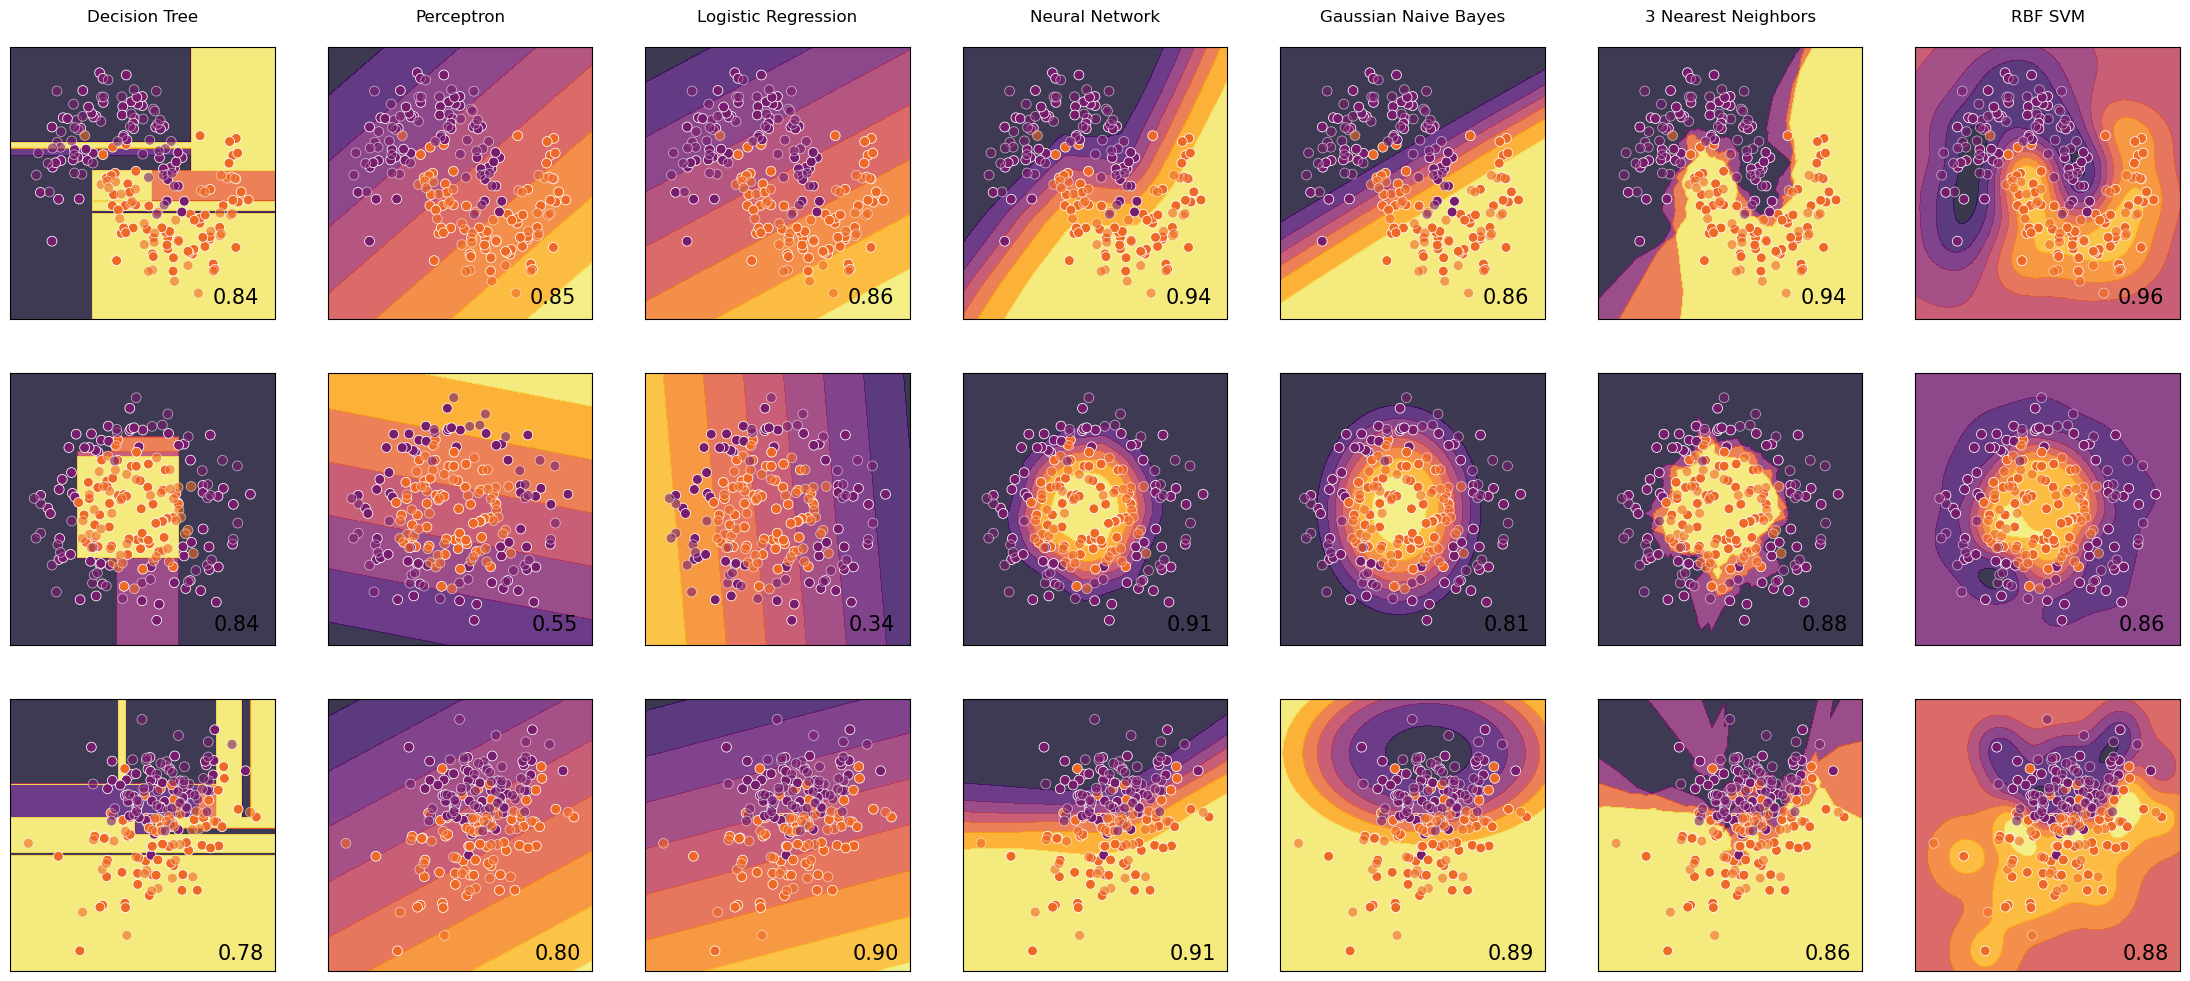

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


def grid(func, *args):  # 计算格点上的函数值 用于后续画等高线或热力图
    x_min, x_max, y_min, y_max = args
    grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))
    grid_z = func(np.column_stack((grid_x.ravel(), grid_y.ravel())))
    grid_z = grid_z.reshape(grid_x.shape)
    return grid_x, grid_y, grid_z


m = 200  # 样本数
X, y = make_classification(n_samples=m, n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1)  # 特征2 有效特征2 冗余特征0 重复特征0 每类1个簇
X += st.uniform.rvs(loc=-1, scale=2, size=X.shape, random_state=2)  # 特征加扰动
datasets = [
    make_moons(n_samples=m, noise=0.2, random_state=0),
    make_circles(n_samples=m, noise=0.2, factor=0.5, random_state=1),
    (X, y)
]

classifiers = [
    ["Decision Tree", DecisionTreeClassifier(max_depth=5)],
    ["Perceptron", Perceptron(eta0=0.5)],
    ["Logistic Regression", LogisticRegression()],
    ["Neural Network", MLPClassifier(alpha=1, max_iter=1000)],
    ["Gaussian Naive Bayes", GaussianNB()],
    ["3 Nearest Neighbors", KNeighborsClassifier(3)],
    ["RBF SVM", SVC(gamma=2, C=1)],
]

figure, ax = plt.subplots(3, 7, figsize=(7 * 4, 3 * 4))

for i, ds in enumerate(datasets):

    X, y = ds
    X = StandardScaler().fit_transform(X)  # 标准化
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=42)  # 训练集、测试集

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5

    for j, (name, clf) in enumerate(classifiers):

        clf.fit(X_train, y_train)  # 训练模型
        score = clf.score(X_test, y_test)  # 测试

        if hasattr(clf, "decision_function"):
            grid_x, grid_y, grid_z = grid(clf.decision_function, x_min, x_max, y_min, y_max)
        else:
            grid_x, grid_y, grid_z = grid(lambda m: clf.predict_proba(m)[:, 1], x_min, x_max, y_min, y_max)

        ax[i, j].contourf(grid_x, grid_y, grid_z, alpha=.8, cmap='inferno')
        sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette="inferno", s=50, legend=False, ax=ax[i, j])
        sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test, palette="inferno", s=50, legend=False, alpha=0.6, ax=ax[i, j])

        ax[i, j].set(xlim=(x_min, x_max), ylim=(y_min, y_max), xticks=(), yticks=())

        if i == 0:
            ax[i, j].set_title(f"{name}\n")
        ax[i, j].text(x_max - .3, y_min + .3, f"{score:.2f}", size=15, horizontalalignment='right')

plt.show()